In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
# Define objective function for c=1.5
def f_rosenbrock(theta, c=1.5):
    """
    Rosenbrock 1D function:
    f(theta) = (1 - theta)^2 + c*(theta^2 - 1)^2
    """
    return (1 - theta)**2 + c * (theta**2 - 1)**2

def extract_params(filename):
    """Extract parameters from filename"""

    # For discrete files: c_X.X_results_initial_theta_Y_lr_Z_beta1_W_beta2_V.csv
    match_discrete = re.search(
        r'c_([\d.]+)_results_initial_theta_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_discrete:
        return {
            'c': float(match_discrete.group(1)),
            'initial_theta': float(match_discrete.group(2)),
            'initial_velocity': None,
            'lr': float(match_discrete.group(3)),
            'beta1': float(match_discrete.group(4)),
            'beta2': float(match_discrete.group(5))
        }

    # For 2nd order: second_order_c_X.X_initial_theta_Y_initial_velocity_Z_lr_W_beta1_V_beta2_U.csv
    match_2nd_order = re.search(
        r'second_order_c_([\d.]+)_initial_theta_([-\d.]+)_initial_velocity_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_2nd_order:
        return {
            'c': float(match_2nd_order.group(1)),
            'initial_theta': float(match_2nd_order.group(2)),
            'initial_velocity': float(match_2nd_order.group(3)),
            'lr': float(match_2nd_order.group(4)),
            'beta1': float(match_2nd_order.group(5)),
            'beta2': float(match_2nd_order.group(6))
        }

    # For 1st order: first_order_c_X.X_initial_theta_Y_initial_velocity_Z_lr_W_beta1_V_beta2_U.csv
    match_1st_order = re.search(
        r'first_order_c_([\d.]+)_initial_theta_([-\d.]+)_initial_velocity_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if match_1st_order:
        return {
            'c': float(match_1st_order.group(1)),
            'initial_theta': float(match_1st_order.group(2)),
            'initial_velocity': float(match_1st_order.group(3)),  # usually 0.0 for 1st order
            'lr': float(match_1st_order.group(4)),
            'beta1': float(match_1st_order.group(5)),
            'beta2': float(match_1st_order.group(6))
        }

    return None

def compute_rho(alpha, beta1, beta2):
    term1 = alpha
    term2 = alpha**2 / (1 - beta1)**2
    term3 = alpha / (1 - beta2)
    rho = max(term1, term2, term3)
    return rho, term1, term2, term3

def exp_plus_floor(t, A, rho, B):
    return A * np.exp(-rho * t) + B

In [ ]:
# Configuration: theta_initial = -1.5, fixed betas
target_initial_theta = -1.5
target_beta1 = 0.99
target_beta2 = 0.999
c_value = 4
f_star = -3.73039
v_

T_horizon = 10

# Continuous integration uses substeps h = alpha/5
SUBSTEP_FACTOR = 5  # dt_continuous = alpha / SUBSTEP_FACTOR

# Directories
results_dir = Path("results")
results_1st_order_dir = Path("results_1rst_order")
results_2nd_order_dir = Path("results_2nd_order")

In [4]:
# Read ALL discrete files
discrete_data_dict = {}
discrete_files = list(results_dir.glob("*.csv"))

for csv_file in discrete_files:
    params = extract_params(str(csv_file))
    if (params and
        params['c'] == c_value and
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        discrete_data_dict[lr] = pd.read_csv(csv_file)
        print(f"Discrete file found: {csv_file.name}, lr={lr}")

# Read 1st order files
results_1st_order = {}
continuous_1st_files = list(results_1st_order_dir.glob("*.csv"))

for csv_file in continuous_1st_files:
    params = extract_params(str(csv_file))
    if (params and
        params['c'] == c_value and
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        results_1st_order[lr] = pd.read_csv(csv_file)
        print(f"1st order file found: {csv_file.name}, lr={lr}")

# Read 2nd order files
results_2nd_order = {}
continuous_2nd_files = list(results_2nd_order_dir.glob("*.csv"))

for csv_file in continuous_2nd_files:
    params = extract_params(str(csv_file))
    if (params and
        params['c'] == c_value and
        params['initial_theta'] == target_initial_theta and
        params['beta1'] == target_beta1 and
        params['beta2'] == target_beta2):
        lr = params['lr']
        v0 = params['initial_velocity']

        if lr not in results_2nd_order:
            results_2nd_order[lr] = {}
        results_2nd_order[lr][v0] = pd.read_csv(csv_file)
        print(f"2nd order file found: {csv_file.name}, lr={lr}, v0={v0}")

Discrete file found: c_4.0_results_initial_theta_-1.5_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001
1st order file found: first_order_c_4.0_initial_theta_-1.5_initial_velocity_0.0_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001
2nd order file found: second_order_c_4.0_initial_theta_-1.5_initial_velocity_1.0_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001, v0=1.0
2nd order file found: second_order_c_4.0_initial_theta_-1.5_initial_velocity_0.0_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001, v0=0.0
2nd order file found: second_order_c_4.0_initial_theta_-1.5_initial_velocity_-1.0_lr_0.001_beta1_0.99_beta2_0.999.csv, lr=0.001, v0=-1.0


KeyError: 'iteration'

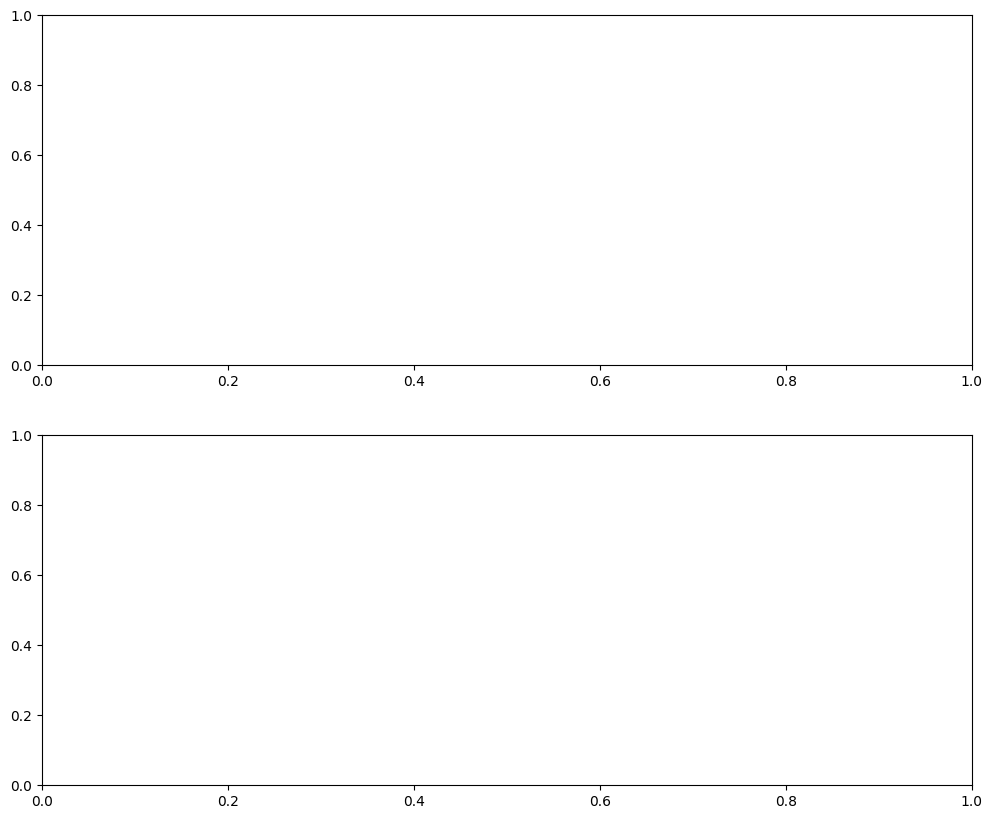

In [5]:
# Create plots for discrete data
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Sort learning rates
sorted_lrs = sorted(discrete_data_dict.keys())

colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_lrs)))

# First subplot: semilog of f(theta(t)) - f*
ax = axes[0]
for i, lr in enumerate(sorted_lrs):
    data = discrete_data_dict[lr]
    t = data['iteration']
    theta = data['theta']
    f_vals = f_rosenbrock(theta, c=c_value)
    f_error = f_vals - f_star
    
    # Filter out values <= 0 for log plot
    mask = f_error > 0
    t_filtered = t[mask]
    f_error_filtered = f_error[mask]
    
    # Compute rho
    rho, t1, t2, t3 = compute_rho(lr, target_beta1, target_beta2)
    
    # Plot data
    ax.semilogy(t_filtered, f_error_filtered, 'o-', alpha=0.6, 
                color=colors[i], label=f'lr={lr:.4f}, ρ={rho:.4f}', markersize=3)
    
    # Try to fit exponential + floor
    if len(t_filtered) > 10:
        try:
            # Initial guess: A = first value, B = last value (floor), rho from theory
            A0 = f_error_filtered.iloc[0] - f_error_filtered.iloc[-1]
            B0 = f_error_filtered.iloc[-1]
            
            # Fit with fixed rho from theory
            def exp_plus_floor_fixed_rho(t, A, B):
                return A * np.exp(-rho * t) + B
            
            popt, _ = curve_fit(exp_plus_floor_fixed_rho, t_filtered, f_error_filtered,
                              p0=[A0, B0], maxfev=10000)
            A_fit, B_fit = popt
            
            # Plot fitted curve
            t_fit = np.linspace(t_filtered.min(), t_filtered.max(), 200)
            f_fit = A_fit * np.exp(-rho * t_fit) + B_fit
            ax.semilogy(t_fit, f_fit, '--', color=colors[i], alpha=0.8, linewidth=2)
            
        except Exception as e:
            print(f"Could not fit lr={lr}: {e}")

ax.set_xlabel('Iteration t', fontsize=12)
ax.set_ylabel('f(θ(t)) - f*', fontsize=12)
ax.set_title(f'Convergencia Semilog: f(θ(t)) - f* con ajuste exponencial + floor\n(c={c_value}, θ₀={target_initial_theta}, β₁={target_beta1}, β₂={target_beta2})', fontsize=13)
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3, which='both')

# Second subplot: show the rho values vs learning rate
ax2 = axes[1]
rho_values = []
for lr in sorted_lrs:
    rho, t1, t2, t3 = compute_rho(lr, target_beta1, target_beta2)
    rho_values.append(rho)
    # Also plot individual terms
    ax2.plot(lr, t1, 'o', color='blue', markersize=8)
    ax2.plot(lr, t2, 's', color='red', markersize=8)
    ax2.plot(lr, t3, '^', color='green', markersize=8)

ax2.plot(sorted_lrs, rho_values, 'ko-', linewidth=2, markersize=10, label='ρ = max(α, α²/(1-β₁)², α/(1-β₂))')
ax2.plot(sorted_lrs, sorted_lrs, 'b--', alpha=0.5, label='α')
ax2.plot(sorted_lrs, [lr**2/(1-target_beta1)**2 for lr in sorted_lrs], 'r--', alpha=0.5, label='α²/(1-β₁)²')
ax2.plot(sorted_lrs, [lr/(1-target_beta2) for lr in sorted_lrs], 'g--', alpha=0.5, label='α/(1-β₂)')

ax2.set_xlabel('Learning Rate (α)', fontsize=12)
ax2.set_ylabel('ρ', fontsize=12)
ax2.set_title('Tasa de convergencia ρ vs Learning Rate', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig(f'plots/semilog_convergence_rho_c_{c_value}_theta0_{target_initial_theta}.png', dpi=300, bbox_inches='tight')
plt.show()

# Print rho values
print("\nValores de ρ para cada learning rate:")
print("-" * 70)
for lr in sorted_lrs:
    rho, t1, t2, t3 = compute_rho(lr, target_beta1, target_beta2)
    print(f"lr={lr:.4f}: ρ={rho:.6f} | α={t1:.6f}, α²/(1-β₁)²={t2:.6f}, α/(1-β₂)={t3:.6f}")